In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [4]:
data = "../data/heart-disease-UCI.csv"

df = pd.read_csv(data)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
df.shape

(303, 14)

In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [15]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

In [7]:
df = df.drop_duplicates()

In [8]:
print("\nMissing values before dropna:\n", df.isnull().sum())
df = df.dropna()
print("Shape after dropping NaNs:", df.shape)


Missing values before dropna:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Shape after dropping NaNs: (302, 14)


In [9]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
scaler = StandardScaler()
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [11]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,0.682656,1.976470,0.764066,-0.261285,2.389793,-1.002541,0.018826,-0.698344,1.084022,-2.271182,-0.714911,-2.147955,0.917313
1,-1.928548,0.682656,1.005911,-0.091401,0.067741,-0.418446,0.901657,1.636979,-0.698344,2.118926,-2.271182,-0.714911,-0.513994,0.917313
2,-1.485726,-1.464866,0.035352,-0.091401,-0.822564,-0.418446,-1.002541,0.980971,-0.698344,0.307844,0.979514,-0.714911,-0.513994,0.917313
3,0.174856,0.682656,0.035352,-0.661712,-0.203222,-0.418446,0.901657,1.243374,-0.698344,-0.209608,0.979514,-0.714911,-0.513994,0.917313
4,0.285561,-1.464866,-0.935208,-0.661712,2.080602,-0.418446,0.901657,0.587366,1.431958,-0.382092,0.979514,-0.714911,-0.513994,0.917313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.285561,-1.464866,-0.935208,0.478910,-0.106449,-0.418446,0.901657,-1.161988,1.431958,-0.727060,-0.645834,-0.714911,1.119967,-1.090140
299,-1.042904,0.682656,1.976470,-1.232023,0.338703,-0.418446,0.901657,-0.768384,-0.698344,0.135360,-0.645834,-0.714911,1.119967,-1.090140
300,1.503322,0.682656,-0.935208,0.707035,-1.035462,2.389793,0.901657,-0.374779,-0.698344,2.032684,-0.645834,1.274980,1.119967,-1.090140
301,0.285561,0.682656,-0.935208,-0.091401,-2.235438,-0.418446,0.901657,-1.511859,1.431958,0.135360,-0.645834,0.280034,1.119967,-1.090140


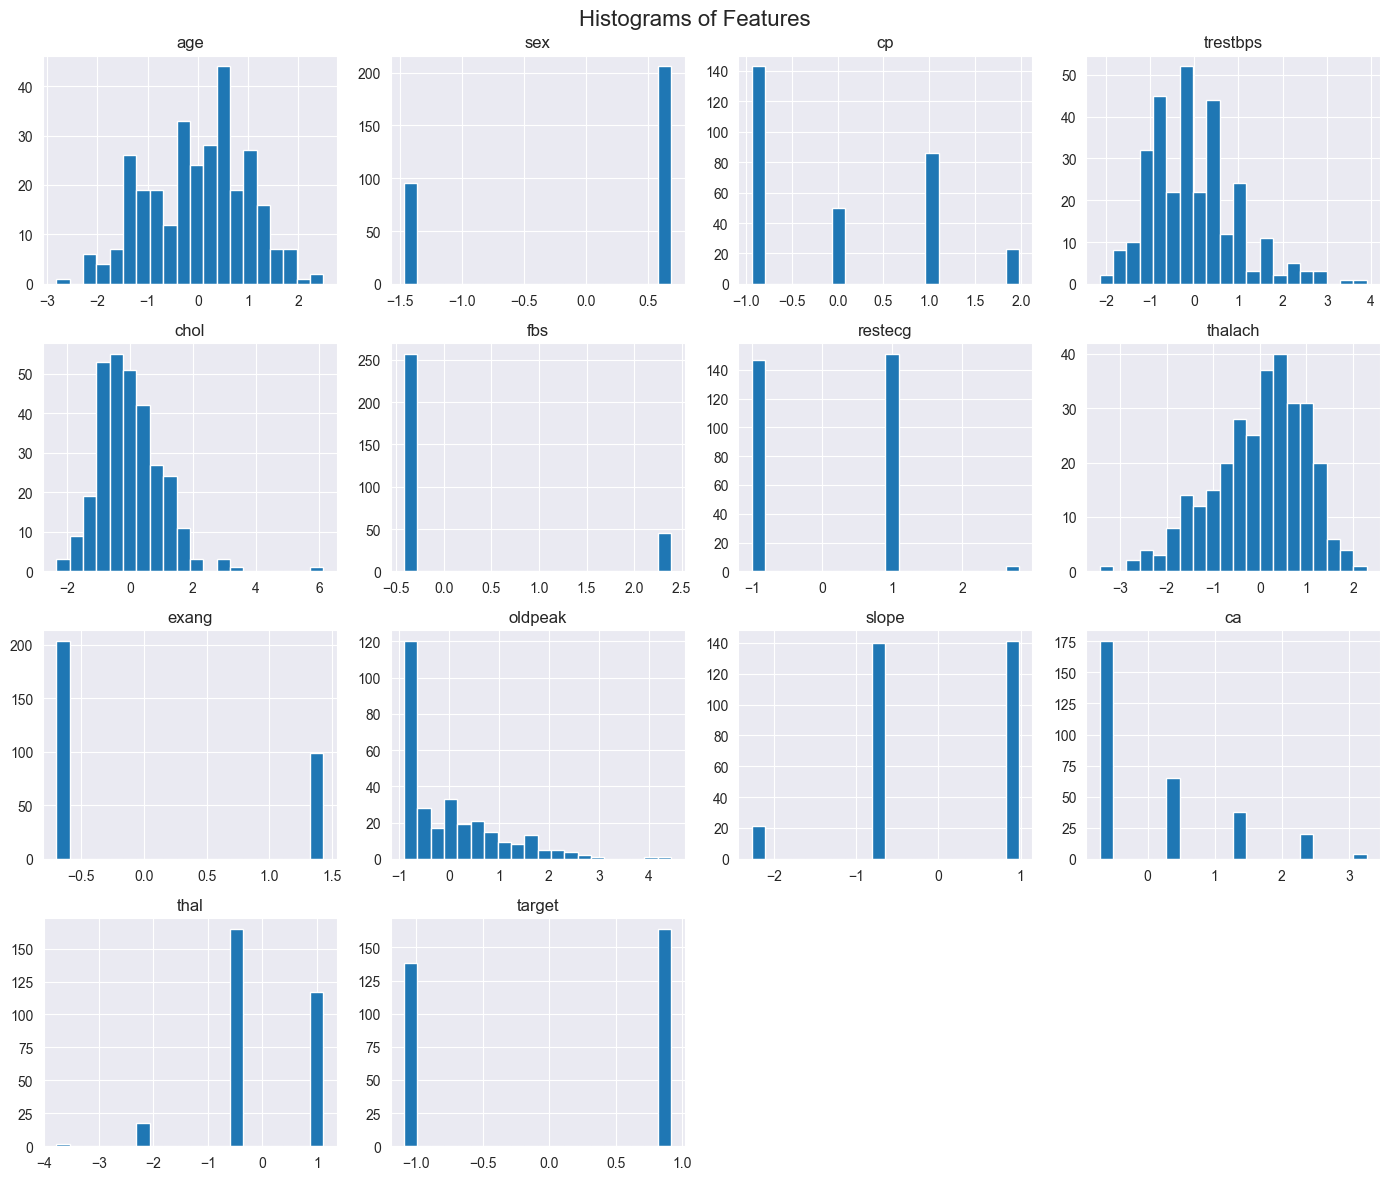

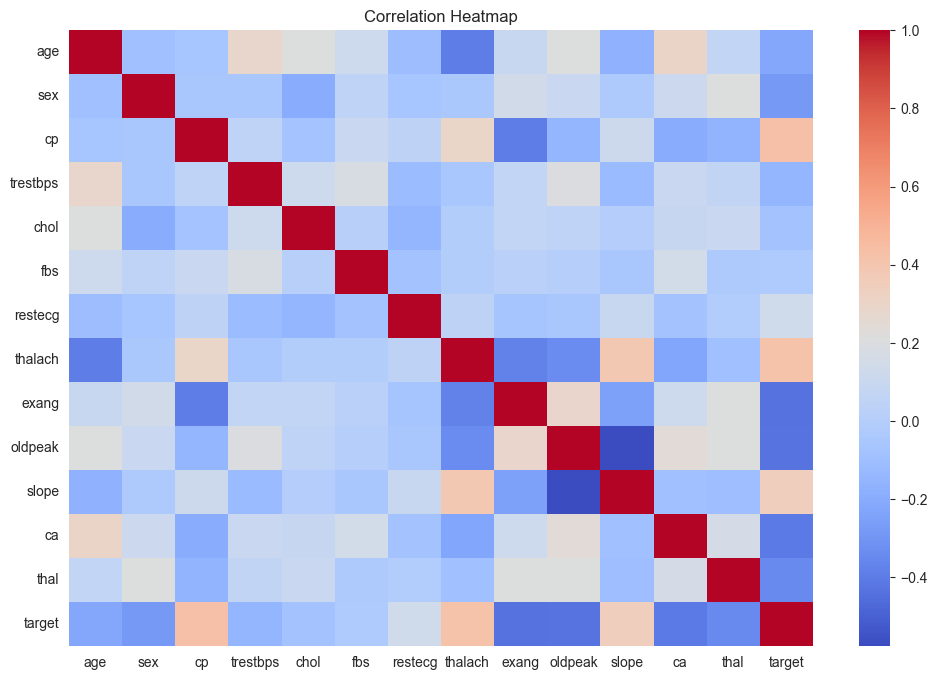

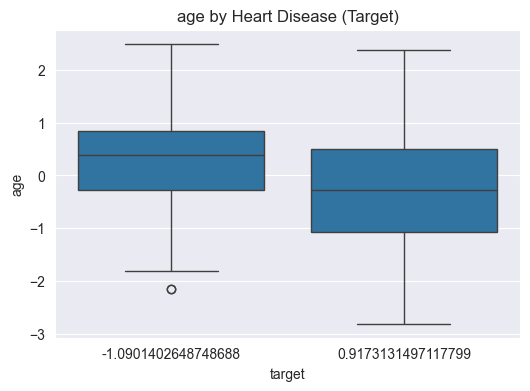

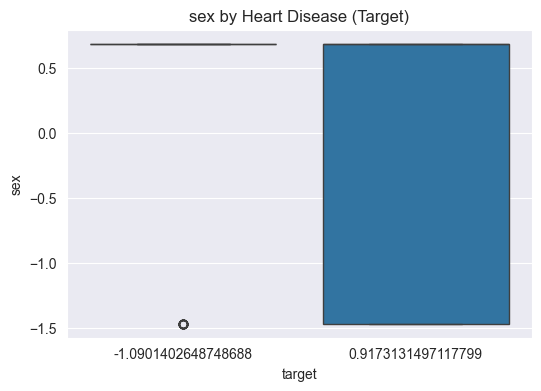

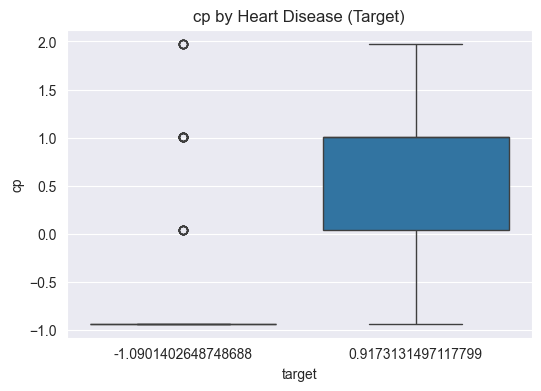

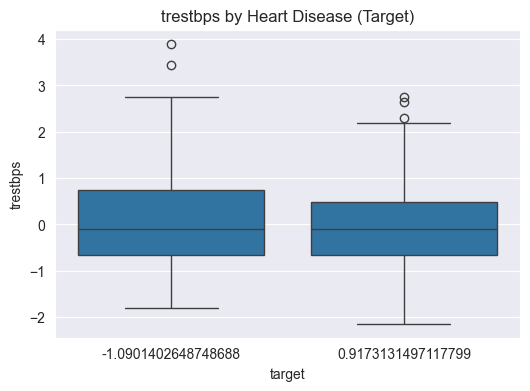

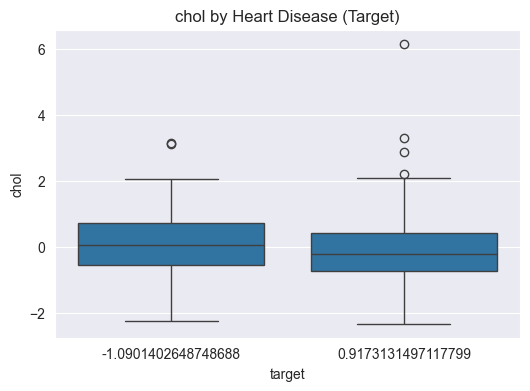

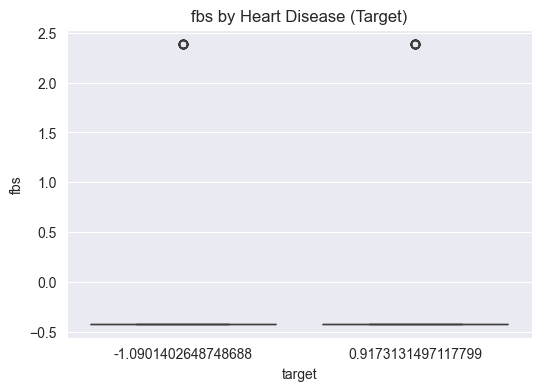

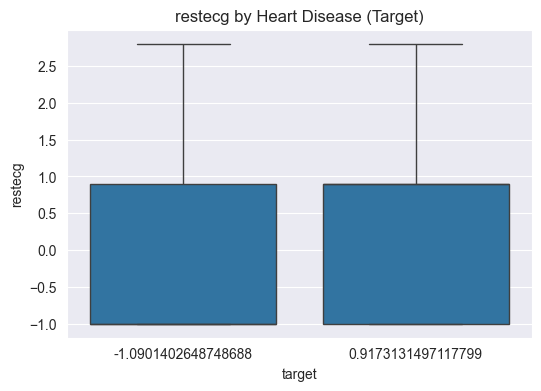

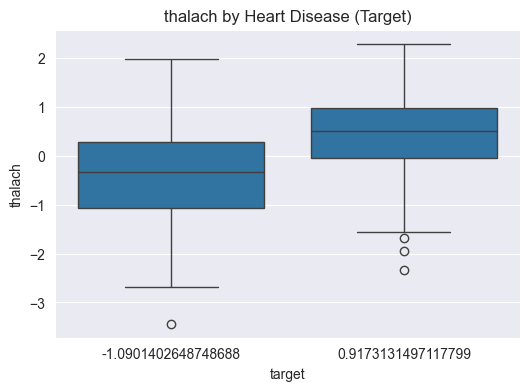

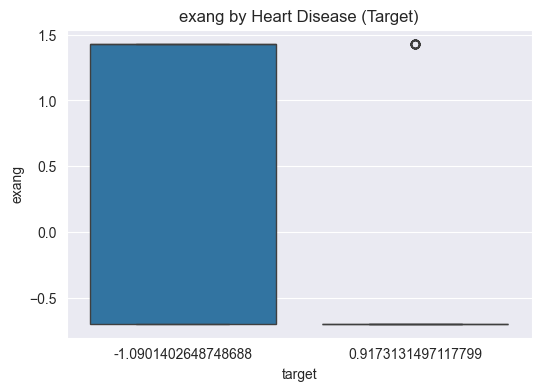

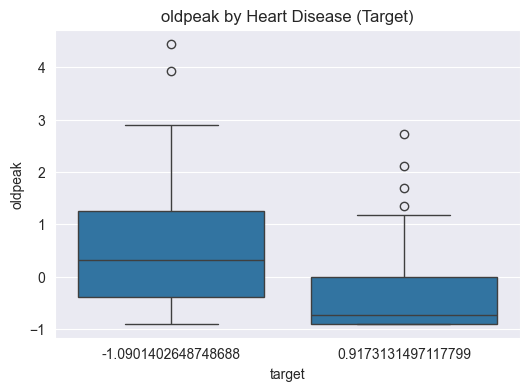

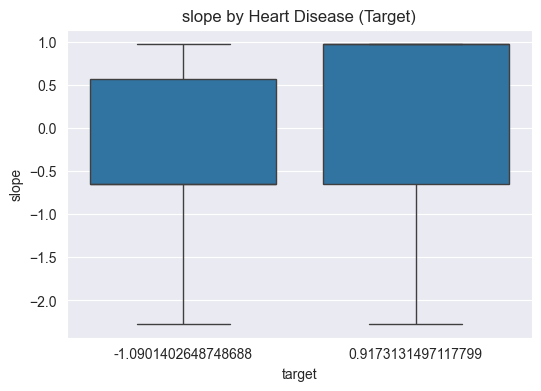

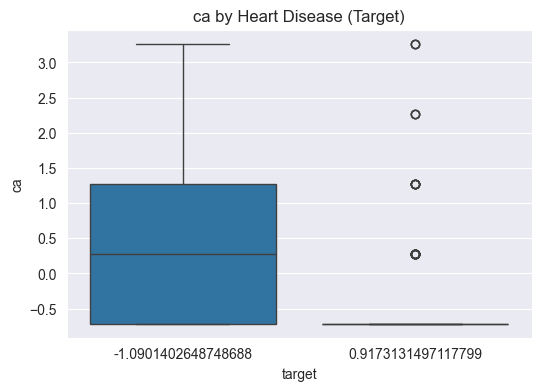

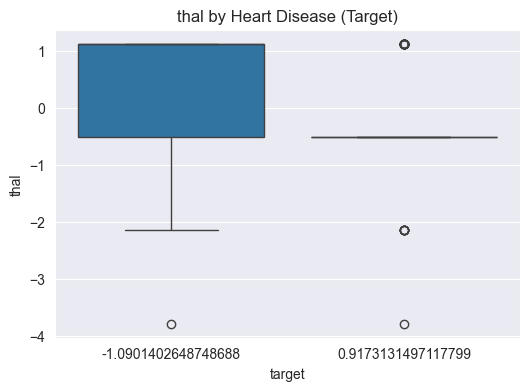

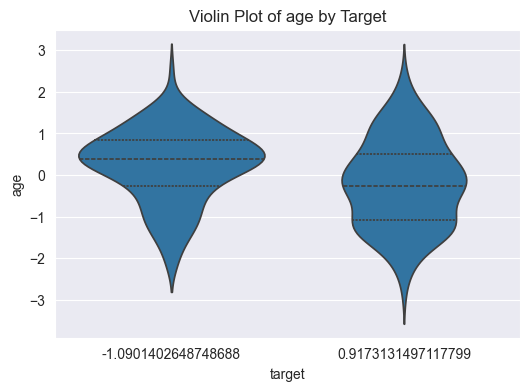

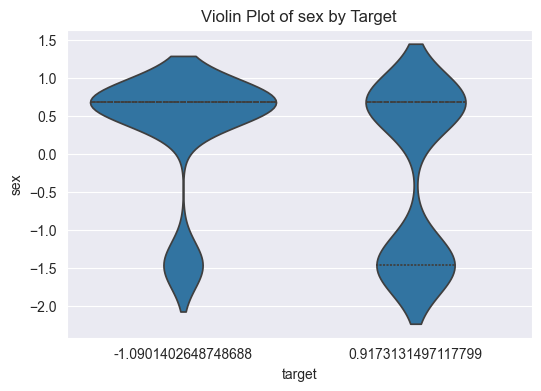

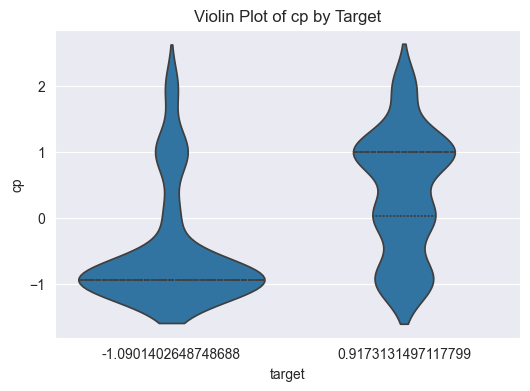

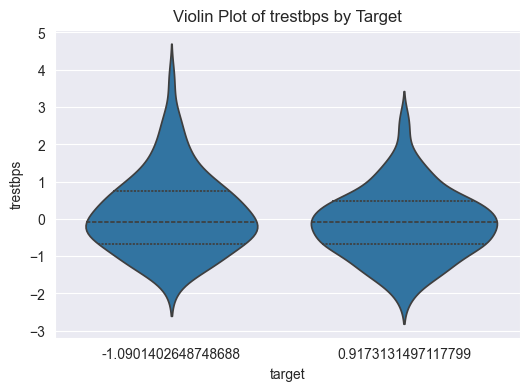

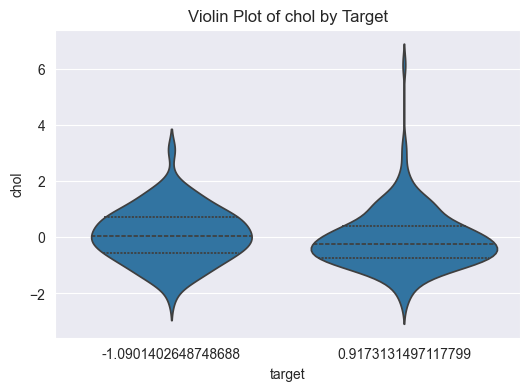

In [14]:
df.hist(figsize=(14, 12), bins=20)
plt.suptitle("Histograms of Features", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


# Boxplots per feature by target (more meaningful than one giant plot)
for col in df.drop(columns=["target"]).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} by Heart Disease (Target)")
    plt.show()

# Violin plots (for richer distributions)
for col in df.drop(columns=["target"]).columns[:5]:  # show only first 5 to avoid too many plots
    plt.figure(figsize=(6, 4))
    sns.violinplot(x="target", y=col, data=df, inner="quartile")
    plt.title(f"Violin Plot of {col} by Target")
    plt.show()

In [13]:
df.to_csv("../data/heart_disease_cleaned.csv", index=False)
